<a href="https://colab.research.google.com/github/Payal795/ML-and-GenAI-with-Python-2026/blob/main/week3_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Q1

import pandas as pd

df = pd.read_csv("agriculture_yield_dataset.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())
print(df.head(10))

Rows: 1500
Columns: 8
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil_typ

In [3]:
# Q2

print(df.dtypes)

missing = df.isnull().sum()
print(missing)

affected_columns = missing[missing > 0]
print(affected_columns)


rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64
Series([], dtype: int64)


In [4]:
# Q3

summary = df.describe()
print(summary)

highest_mean_feature = summary.loc["mean"].idxmax()
highest_std_feature = summary.loc["std"].idxmax()

print("Highest Mean Feature:", highest_mean_feature)
print("Highest Std Feature:", highest_std_feature)


       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

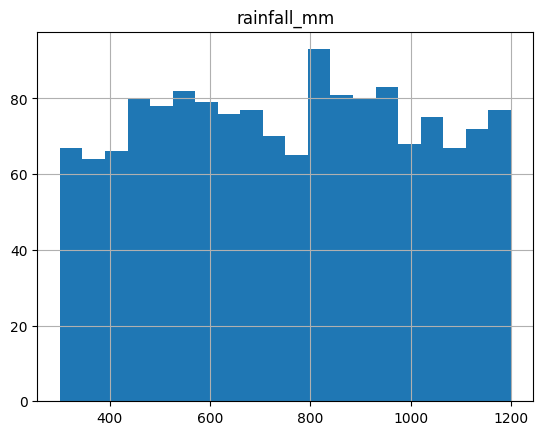

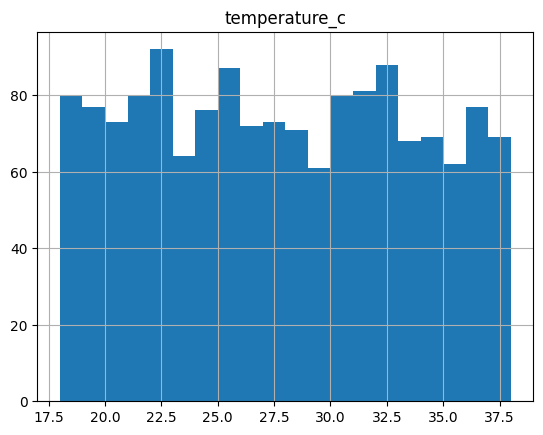

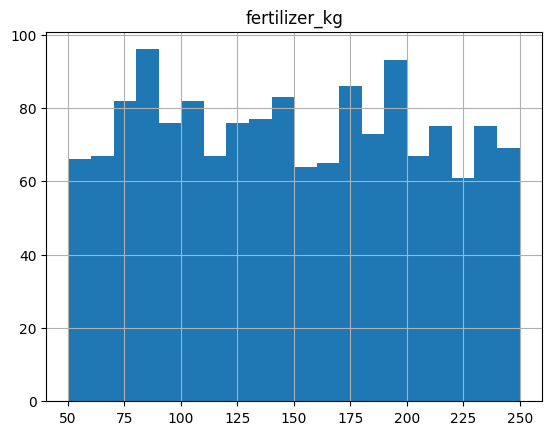

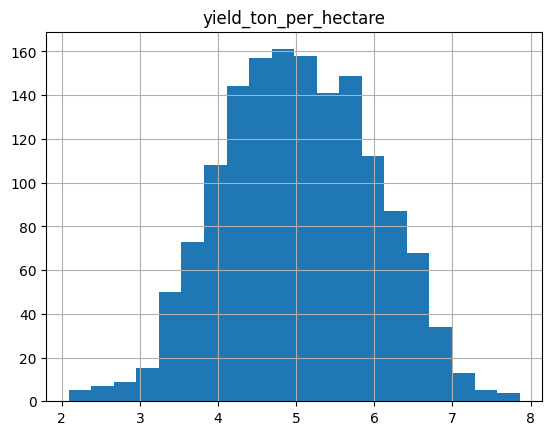

In [5]:
# Q4

import matplotlib.pyplot as plt

df["rainfall_mm"].hist(bins=20)
plt.title("rainfall_mm")
plt.show()

df["temperature_c"].hist(bins=20)
plt.title("temperature_c")
plt.show()

df["fertilizer_kg"].hist(bins=20)
plt.title("fertilizer_kg")
plt.show()

df["yield_ton_per_hectare"].hist(bins=20)
plt.title("yield_ton_per_hectare")
plt.show()



crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


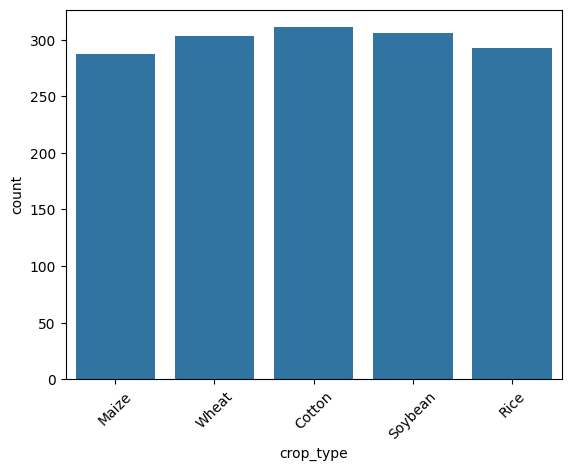

Most Frequent Crop: Cotton


In [6]:
# Q5

import seaborn as sns
import matplotlib.pyplot as plt

crop_counts = df["crop_type"].value_counts()
print(crop_counts)

sns.countplot(x="crop_type", data=df)
plt.xticks(rotation=45)
plt.show()

print("Most Frequent Crop:", crop_counts.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


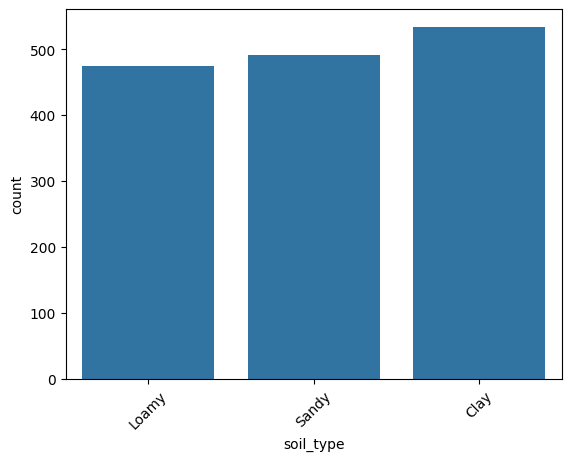

Most Common Soil Type: Clay


In [7]:
# Q6

soil_counts = df["soil_type"].value_counts()
print(soil_counts)

sns.countplot(x="soil_type", data=df)
plt.xticks(rotation=45)
plt.show()

print("Most Common Soil Type:", soil_counts.idxmax())

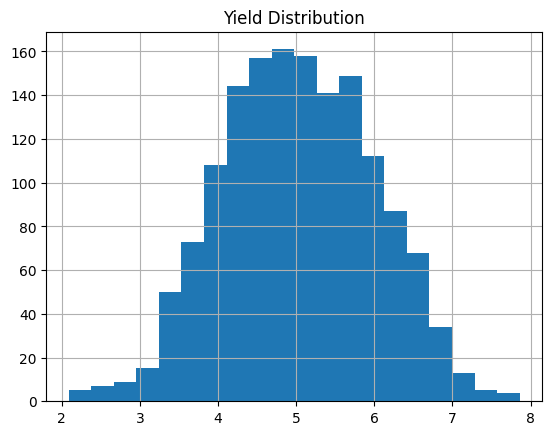

In [8]:
# Q7

df["yield_ton_per_hectare"].hist(bins=20)
plt.title("Yield Distribution")
plt.show()


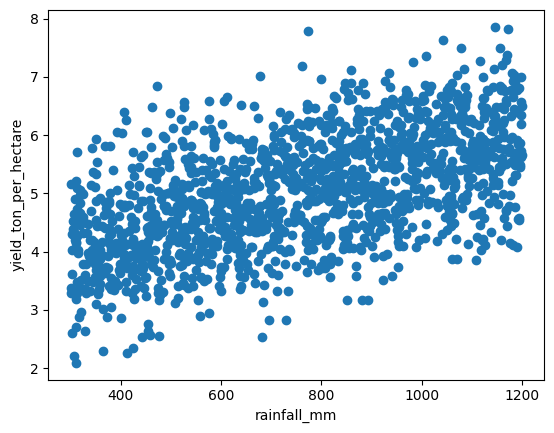

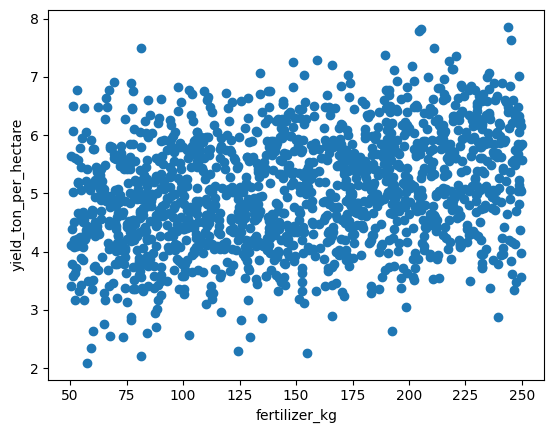

In [9]:
# Q8

plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("rainfall_mm")
plt.ylabel("yield_ton_per_hectare")
plt.show()

plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("fertilizer_kg")
plt.ylabel("yield_ton_per_hectare")
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

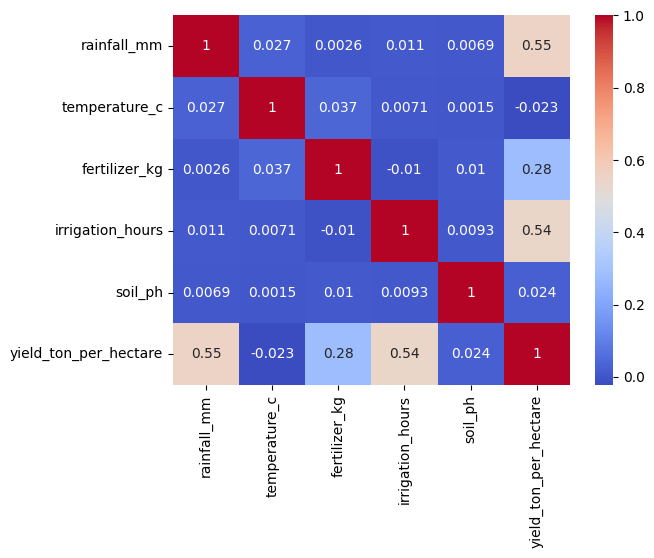

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [10]:
# Q9

corr_matrix = df.select_dtypes(include="number").corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

yield_corr = corr_matrix["yield_ton_per_hectare"].drop("yield_ton_per_hectare")
top_three = yield_corr.abs().sort_values(ascending=False).head(3)

print(top_three)

In [11]:
# Q10

avg_crop_yield = df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print(avg_crop_yield)

avg_soil_yield = df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print(avg_soil_yield)

print("Highest Yield Crop:", avg_crop_yield.idxmax())
print("Highest Yield Soil:", avg_soil_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Yield Crop: Rice
Highest Yield Soil: Loamy


In [12]:
# Q11

categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat

In [13]:
# Q12

X = df_encoded.drop("yield_ton_per_hectare", axis=1)
y = df_encoded["yield_ton_per_hectare"]

print("Target Variable:", "yield_ton_per_hectare")
print(X.head())
print(y.head())

Target Variable: yield_ton_per_hectare
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_type_Wheat  \
0             True           False              False            False   
1             True           False              False            False   
2            False           False              False             True   
3             True           False              False            False   
4            False           False              False            False   

   soil_type_Loamy  soil_type_Sandy  
0             True         

In [14]:
# Q13

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [15]:
# Q14

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

highest_positive_feature = coefficients.loc[
    coefficients["Coefficient"].idxmax(),
    "Feature"
]

print("Highest Positive Coefficient Feature:", highest_positive_feature)

Intercept: 1.587132027736121
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933
Highest Positive Coefficient Feature: crop_type_Rice
